# OVERVIEW
This notebook serves as an example, and analysis of, the attached src notebook files

## *IMPORTS*

Script created in trading_bot project when encountering import issues due to notebook files and working in a different directory. same script added across every project. Also changed the names of plotting files to match the project name, as python automatically was chosing the first option when called. 

In [94]:
import sys
from pathlib import Path
if not globals().get("_TRADING_PORTFOLIO_PATHS_READY"):
    _HERE = (
        Path(__file__).resolve().parent
        if "__file__" in globals()
        else Path.cwd().resolve()
    )
    _PROJECTS = (
        "past_market_analysis",
        "technical_analysis",
        "options_pricing",
        "time_series_forecasting",
        "portfolio_construction",
        "ml_fundamentals",
        "ml_trading_signals",
        "risk_management",
        "trading_bot",
    )
    _REPO_ROOT = next(
        (
            directory
            for directory in (_HERE, *_HERE.parents)
            if all((directory / project).is_dir() for project in _PROJECTS)
        ),
        None,
    )
    if _REPO_ROOT is None:
        raise RuntimeError(
            "Could not locate the trading_portfolio repository root."
        )
    _SRC_PATHS = [
        str((_REPO_ROOT / project / "src").resolve())
        for project in _PROJECTS
    ]
    sys.path.extend(path for path in _SRC_PATHS if path not in sys.path)
    _TRADING_PORTFOLIO_PATHS_READY = True


In [95]:
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal

from data_loader import fetch_price_data, load_data
from risk_metrics import build_returns_matrix, annualised_stats, correlation_matrix, shrunk_covariance, risk_contributions
from optimisation import portfolio_stats, min_variance_portfolio, max_sharpe_portfolio, risk_parity_portfolio, efficient_frontier, stability_test, stability_test_shrunk, out_of_sample_test, compare_shorting,  turnover_analysis
from plotting_portfolio_construction import plot_efficient_frontier, plot_shorting_comparison
from covariance_forecasting import sample_covariance, ledoit_wolf_covariance, ewma_covariance, blend_covariances


## **Analysis**

This notebooks focuses on the simple question, "given a selection of assets, what is the best way to weight the portolio?"
We start by building the returns and correlation matrices alongside annualised means

In [96]:
tickers = ["AAPL", "NVDA", "SPY", "JNJ", "GLD", "TSLA"]
returns_df = build_returns_matrix(tickers, period="5y")

print(f"Shape: {returns_df.shape}")
print(returns_df.head())

mu, cov = annualised_stats(returns_df)
print("\nAnnualised expected returns:")
print((mu * 100).round(2))

print("\nCorrelation matrix:")
print(correlation_matrix(returns_df).round(3))

Shape: (1254, 6)
                AAPL      NVDA       SPY       JNJ       GLD      TSLA
Date                                                                  
2021-09-14 -0.009562  0.004063 -0.005396 -0.006031  0.006439  0.002005
2021-09-15  0.006144  0.004451  0.008353  0.003762 -0.005864  0.015232
2021-09-16 -0.001610 -0.004431 -0.001585 -0.001209 -0.022642  0.001535
2021-09-17 -0.018348 -0.015376 -0.009741 -0.002845 -0.001585  0.003303
2021-09-20 -0.021361 -0.035936 -0.016674 -0.005706  0.007144 -0.038605

Annualised expected returns:
AAPL    20.47
NVDA    59.49
SPY     13.64
JNJ     13.82
GLD     19.19
TSLA    25.68
dtype: float64

Correlation matrix:
       AAPL   NVDA    SPY    JNJ    GLD   TSLA
AAPL  1.000  0.472  0.718  0.139  0.051  0.461
NVDA  0.472  1.000  0.707 -0.118  0.087  0.462
SPY   0.718  0.707  1.000  0.156  0.149  0.583
JNJ   0.139 -0.118  0.156  1.000  0.050 -0.040
GLD   0.051  0.087  0.149  0.050  1.000  0.061
TSLA  0.461  0.462  0.583 -0.040  0.061  1.000


We see that there is a diverse selection of assets chosen, with JNJ having minimal correlation with all other assets chosen. Similarly with gold. We now look at different common ways to weight these assets within a portfolio.

In [97]:
mu_arr = mu.values
cov_arr = cov.values

#equal-weight portfolio
n = len(tickers)
w_equal = np.repeat(1/n, n)
ret, vol, sharpe = portfolio_stats(w_equal, mu_arr, cov_arr)
print(f"Equal weight:   return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")

# minimum variance portfolio
w_minvar = min_variance_portfolio(mu_arr, cov_arr)
ret, vol, sharpe = portfolio_stats(w_minvar, mu_arr, cov_arr)
print(f"Min variance:   return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")
print(dict(zip(tickers, w_minvar.round(3))))

# max sharpe portfolio
w_sharpe = max_sharpe_portfolio(mu_arr, cov_arr)
ret, vol, sharpe = portfolio_stats(w_sharpe, mu_arr, cov_arr)
print(f"Max Sharpe:     return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")
print(dict(zip(tickers, w_sharpe.round(3))))

Equal weight:   return 25.38%, vol 22.01%, Sharpe 1.153
Min variance:   return 15.39%, vol 11.46%, Sharpe 1.342
{'AAPL': np.float64(0.0), 'NVDA': np.float64(0.0), 'SPY': np.float64(0.334), 'JNJ': np.float64(0.363), 'GLD': np.float64(0.303), 'TSLA': np.float64(0.0)}
Max Sharpe:     return 24.52%, vol 14.35%, Sharpe 1.709
{'AAPL': np.float64(0.004), 'NVDA': np.float64(0.188), 'SPY': np.float64(0.0), 'JNJ': np.float64(0.418), 'GLD': np.float64(0.39), 'TSLA': np.float64(0.0)}


We see that the max-sharpe portfolio gives basically the same returns as the equal weight, but with 7% less risk, making it a significantly better choice. Infact, we now look the efficient frontier, a plot which gives the 'optimal' line for annualised expected returns vs risk taken.

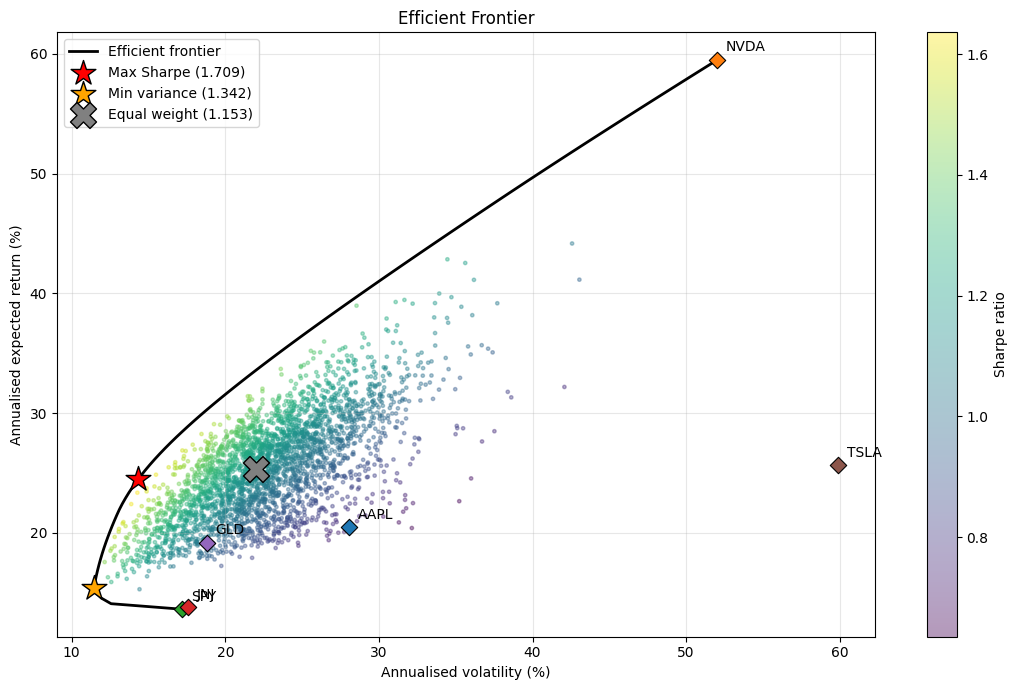

In [98]:
#as stated in plotting.py, the portfolios input takes in a dictionary of form: {label: (weights, colours, marker)}
vols, rets, weights = efficient_frontier(mu_arr, cov_arr, num_points=100)

portfolios = {
    'Max Sharpe':   (w_sharpe, 'red',    '*'),
    'Min variance': (w_minvar, 'orange', '*'),
    'Equal weight': (w_equal,  'grey',   'X'),
}

plot_efficient_frontier(mu_arr, cov_arr, tickers, vols, rets, portfolios=portfolios)

Each scatter point corresponds to a portfolio with different weights. The efficient frontier is the optimal weights when measured by returns and risk. For examaple, if you target 30% returns with this portfolio, you would need to take on ~19% risk. We also see how far away the equal-weighted portfolio is from the efficient frontier, highlighting how much it could be optimised. We now move on to discuss the stability of these portfolios.

In [99]:
stability = stability_test(returns_df, n_periods=4)
print("Max-Sharpe weights by sub-period:\n")
print((stability * 100).round(1))

print("\nWeight standard deviation across periods (pp):")
print((stability.std() * 100).round(1))

Max-Sharpe weights by sub-period:

                          AAPL  NVDA   SPY   JNJ   GLD  TSLA
2021-09-14 to 2022-12-09   0.0   0.0   0.0  89.0  11.0   0.0
2022-12-12 to 2024-03-13   0.0  36.4   2.2   0.0  61.4   0.0
2024-03-14 to 2025-06-12   0.0   6.1   0.0  11.6  74.6   7.7
2025-06-13 to 2026-09-11  16.8   9.6  23.2  48.5   1.9   0.0

Weight standard deviation across periods (pp):
AAPL     8.4
NVDA    16.1
SPY     11.3
JNJ     40.2
GLD     36.1
TSLA     3.9
dtype: float64


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We see above that the weights are changing drastically per ticker per period, GLD, JNJ being the most alarming 2. This tells us that the system is primarily 'fitting the data' and not providing too much insight. It also requires us to liquidate each asset the system doesn't like every time, which is not too feasible. This is an issue, as the system entirely removes tickers it doesn't like. We seek to adapt it using Lediot-Wolf shrinkage.

This instabilty comes from our assets having to estimate too many quantites (all variances and all covariances) so any change can change these significantly(Mathematically, the covariance matrix could in theory have zero determinant, or very close to, and hence the problem is not well posed). We try to counteract this by taking a convex combination of a sample and a target (alternatively a weighted average), represented by this formula
$$
\Sigma_{shrunk} =(1 - \delta) \Sigma_{sample} + \delta F
$$
where F is our target and $ \delta $ is our shrinkage intensity and controls the blend. F is often a matrix assuming all assets share a common variance and single common correlation, which is almost certainly wrong, but its stable, and Ledoit-Wolf let us find the optimal $\delta$ to minimise least-squares error to data.

In [100]:
cov_shrunk, delta = shrunk_covariance(returns_df)
print(f"Shrinkage intensity: {delta:.4f}")

# Compare optimal weights: sample vs shrunk
w_sample = max_sharpe_portfolio(mu_arr, cov_arr)
w_shrunk = max_sharpe_portfolio(mu_arr, cov_shrunk)

comparison = pd.DataFrame({
    'Sample covariance': (w_sample * 100).round(1),
    'Shrunk covariance': (w_shrunk * 100).round(1)
}, index=tickers)
print("\nOptimal weights (%):")
print(comparison)
print()
stab_shrunk = stability_test_shrunk(returns_df, n_periods=4)
print((stab_shrunk * 100).round(1))
print("\nStd dev with shrinkage (pp):")
print((stab_shrunk.std() * 100).round(1))

Shrinkage intensity: 0.0099

Optimal weights (%):
      Sample covariance  Shrunk covariance
AAPL                0.4                0.8
NVDA               18.8               19.1
SPY                 0.0                0.0
JNJ                41.8               41.2
GLD                39.0               38.8
TSLA                0.0                0.0

                    AAPL  NVDA   SPY   JNJ   GLD  TSLA
2021-09 to 2022-12   0.0   0.0   0.0  89.4  10.6   0.0
2022-12 to 2024-03   0.0  40.2   4.8   0.0  55.0   0.0
2024-03 to 2025-06   0.0   7.7   0.0  12.1  70.9   9.3
2025-06 to 2026-09  18.8  11.0  18.9  48.4   3.0   0.0

Std dev with shrinkage (pp):
AAPL     9.4
NVDA    17.6
SPY      9.0
JNJ     40.2
GLD     33.2
TSLA     4.6
dtype: float64


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We see that this approach has not particularly improved our issues. This is due to the actual issue here being the volatility of the returns over these periods, as seen below. The process above does improve things in a general theoretical sense though, as in principle the covariance matrix is likely unstable (determinant = 0 or very close to) and our process stabilises the matrix $ \forall \delta \in [0,1]$, with Ledoit-Wolf choosing the $\delta$ that minimises the operator norms of the 2 matrices.

In [101]:
splits = np.array_split(returns_df, 4)
means = pd.DataFrame([chunk.mean() * 252 * 100 for chunk in splits], index=[f"Period {i+1}" for i in range(4)])
print("Annualised mean returns by period (%):")
print(means.round(1))
print("\nStd dev across periods (pp):")
print(means.std().round(1))

Annualised mean returns by period (%):
          AAPL   NVDA   SPY   JNJ   GLD  TSLA
Period 1   2.0   -2.5  -6.2   8.7   0.7  -6.0
Period 2  17.7  146.9  24.2  -2.7  15.8  10.9
Period 3  17.6   53.8  15.7   2.7  36.9  75.9
Period 4  44.7   39.6  20.9  46.7  23.4  22.0

Std dev across periods (pp):
AAPL    17.7
NVDA    63.0
SPY     13.7
JNJ     22.4
GLD     15.1
TSLA    35.4
dtype: float64


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We see that the returns are precisely the issue here and to combat this, we discuss risk parity, where we look at the assets risk per weighting it has in the portfolio. The idea is to choose asset weightings such that every asset has equal risk.

In [102]:
weight_rp = risk_parity_portfolio(cov_arr)
ret, vol, sharpe = portfolio_stats(weight_rp, mu_arr, cov_arr)

print(f"Risk parity: return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")
print("\nWeights (%):")
print(pd.Series(weight_rp * 100, index=tickers).round(1))

_, contrib_pct = risk_contributions(weight_rp, cov_arr)
print("\nRisk contributions (%) — should all be ~16.7:")
print(pd.Series(contrib_pct * 100, index=tickers).round(1))

_, contrib_equal = risk_contributions(w_equal, cov_arr)
print("\nRisk contributions under EQUAL weighting (%):")
print(pd.Series(contrib_equal * 100, index=tickers).round(1))

Risk parity: return 20.06%, vol 14.10%, Sharpe 1.423

Weights (%):
AAPL    11.9
NVDA     7.2
SPY     16.5
JNJ     31.1
GLD     27.0
TSLA     6.3
dtype: float64

Risk contributions (%) — should all be ~16.7:
AAPL    16.7
NVDA    16.7
SPY     16.7
JNJ     16.7
GLD     16.6
TSLA    16.7
dtype: float64

Risk contributions under EQUAL weighting (%):
AAPL    15.5
NVDA    31.2
SPY     11.3
JNJ      1.7
GLD      3.4
TSLA    36.9
dtype: float64


We see here that now the weightings of each asset are such that each one of them contributes to the risk of the portfolio equally. We show below where this portfolio lies relative to the efficient frontier.

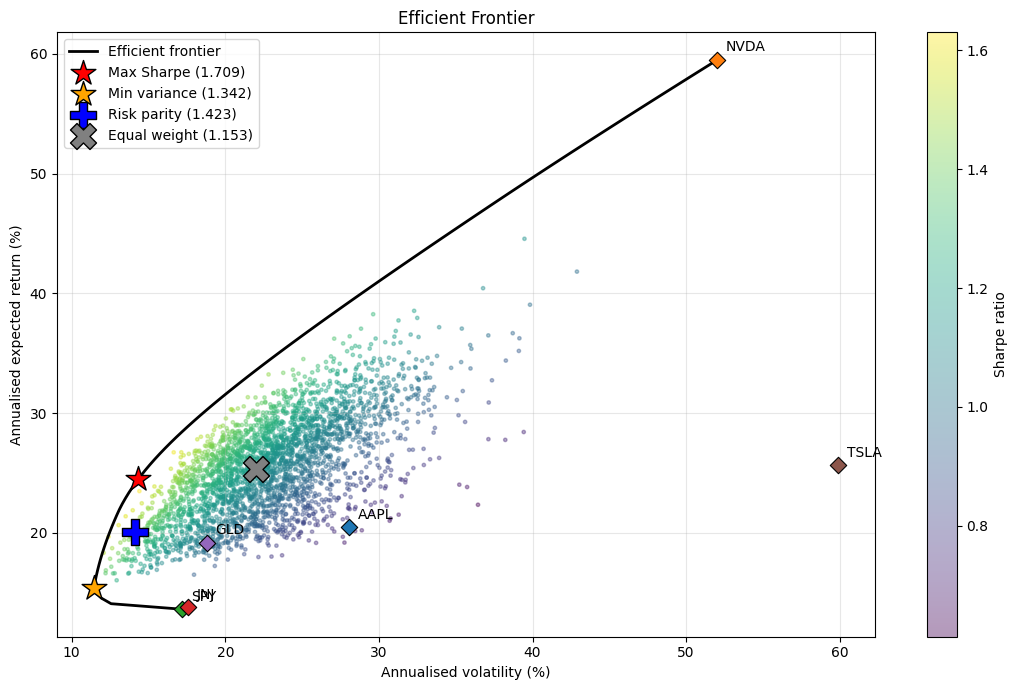

In [103]:

portfolios = {
    'Max Sharpe':   (w_sharpe, 'red',    '*'),
    'Min variance': (w_minvar, 'orange', '*'),
    'Risk parity':  (weight_rp,     'blue',   'P'),
    'Equal weight': (w_equal,  'grey',   'X'),
}

plot_efficient_frontier(mu_arr, cov_arr, tickers, vols, rets, portfolios=portfolios)

We see that it doesn't lay directly on the efficent frontier, but pretty close to it, and on the lower volatility side of the plot in general. It achieves near optimal returns (per unit risk) without using any returns data what-so-ever. It gives a pretty safe way to structure a portfolio and a significantly better way than the equal weighting. We now impose a out of sample test, where we choose weightings based on the different portfolios defined on the first period, and see how they perform on the second period.

In [104]:
results, weights_oos = out_of_sample_test(returns_df, train_frac=0.6)

print("Performance:")
print(results)

print("\nWeights from training period (%):")
print((weights_oos * 100).round(1))

print("\nSharpe degradation (IS → OOS):")
print((results['OOS_Sharpe'] - results['IS_Sharpe']).round(3))

Train: 2021-09-14 to 2024-09-10  (752 days)
Test:  2024-09-11 to 2026-09-11  (502 days)

Performance:
                     IS_return  IS_vol  IS_Sharpe  OOS_return  OOS_vol  \
Strategy                                                                 
Max Sharpe               23.31   15.79      1.476       33.00    18.32   
Max Sharpe (shrunk)      23.88   16.19      1.475       33.16    18.39   
Min variance              9.18   10.29      0.892       27.18    14.39   
Risk parity              13.62   13.09      1.040       28.88    14.17   
Equal weight             21.26   22.97      0.926       31.55    20.51   

                     OOS_Sharpe  
Strategy                         
Max Sharpe                1.801  
Max Sharpe (shrunk)       1.803  
Min variance              1.889  
Risk parity               2.037  
Equal weight              1.539  

Weights from training period (%):
                     AAPL  NVDA   SPY   JNJ   GLD  TSLA
Max Sharpe            0.0  22.5   0.0  19.7  57.9 

It is key to note that the strategy names follow over, i.e "max sharpe" is the weightings chosen to maximise sharpe ratio over the in-sample data, hence why it is possible for it to not be the maximum sharpe ratio portfolio over the out-of-sample period. We see that the best performing portfolio was infact the risk parity one, but that every portfolio apart from the max sharpe portfolio. This indicates that the second period was just a better market period for our tickers, so the only conclusions we can take is comparatively. It also shows that the max sharpe ratio is not always the best choice for a portfolio as past performance may not indicate future performance. Something that has not been taken account of so far in any of my project is transaction costs/cost of totally liquidating one asset to move to another. This is where we look at this, and also introduce weight caps (i.e we cannot hold more than 30% of our portfolio in one asset, which helps diversify).

In [105]:
turnover = turnover_analysis(returns_df, n_periods=4, cost_bps=10)
print(turnover)


              Avg turnover  Max turnover  Cost per rebalance (%)
Strategy                                                        
Max Sharpe            67.3          89.0                   0.067
Min variance          26.4          35.6                   0.026
Risk parity           12.7          19.0                   0.013
Equal weight           0.0           0.0                   0.000


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We see here that the max-sharpe portfolio has massive turnover in its assets, sometimes entirely liquidating them based upon the period. This costs significantly, for example if you were to rebalance 4 times annually, thats ~0.3% of your portfolio it costs you, which is significant. Comparitively, the risk parity portfolio does not encounter the same costs as turnover is minimal, just to retain equality in risk. We now see how a weight cap effects the max sharpe portfolio.

In [106]:
print("\n--- Effect of a maximum weight cap ---\n")

rows = []
for cap in [None, 0.5, 0.35, 0.25]:
    w = max_sharpe_portfolio(mu_arr, cov_arr, max_weight=cap)
    ret, vol, sharpe = portfolio_stats(w, mu_arr, cov_arr)
    row = {'Cap': 'None' if cap is None else f'{cap*100:.0f}%', 'Sharpe': round(sharpe, 3), 'Return': round(ret*100, 2), 'Vol': round(vol*100, 2)}
    row.update({t: round(v*100, 1) for t, v in zip(tickers, w)})
    rows.append(row)

print(pd.DataFrame(rows).set_index('Cap').to_string())


--- Effect of a maximum weight cap ---

      Sharpe  Return    Vol  AAPL  NVDA   SPY   JNJ   GLD  TSLA
Cap                                                            
None   1.709   24.52  14.35   0.4  18.8   0.0  41.8  39.0   0.0
50%    1.709   24.52  14.35   0.4  18.8   0.0  41.8  39.0   0.0
35%    1.671   25.59  15.31   9.8  20.2   0.0  35.0  35.0   0.0
25%    1.503   26.53  17.65  13.7  22.9  13.3  25.0  25.0   0.0


As the cap increases, we see a reduced sharpe ratio (as expected) but an increased amount of diversity as we increase the cap. By the 25% cap, we finally have weights in all of our tickers, as wanted for diversity. We see it also has more returns, but significantly more volality, so less sharpe ratio.

We end by discussion around shorting. Mathematically, this allows us to hold negative weights of assets, but our weights need to still sum to 1. This can bring greater returns, but takes on more risk than a long-only portfolio since we have more gross exposure to the market, i.e if we are funded by 150% long, 50% short, then we have correct weights but 200% gross exposure, which brings its own risks.

In [107]:
summary, weights_short = compare_shorting(mu_arr, cov_arr, tickers)
print(summary)
print("\nWeights (%):")
print(weights_short)

                  return    vol  sharpe  gross_exposure  largest_short
Strategy                                                              
Long only          24.52  14.35   1.709          100.00           0.00
Shorting allowed   33.51  18.57   1.804          232.53         -66.27

Weights (%):
                  AAPL  NVDA   SPY   JNJ   GLD  TSLA
Long only          0.4  18.8   0.0  41.8  39.0   0.0
Shorting allowed  18.7  33.8 -66.3  60.9  52.3   0.6


We see that the best portfolio available shorting is by significantly shorting the S%P 500 and investing in other things elsewhere, including assets which are contained in it (AAPL, NVDA), so effectively the system is betting against other tickers in the S&P 500. Even though the volatility isn't too high here, the gross exposure is ~230% compared to 100%. In practical terms, this isn't great as we trade ~5% sharpe for 2.3x leverage. An increase in sharpe doesn't account for the potential risks of the theoretically unbounded losses of a short position

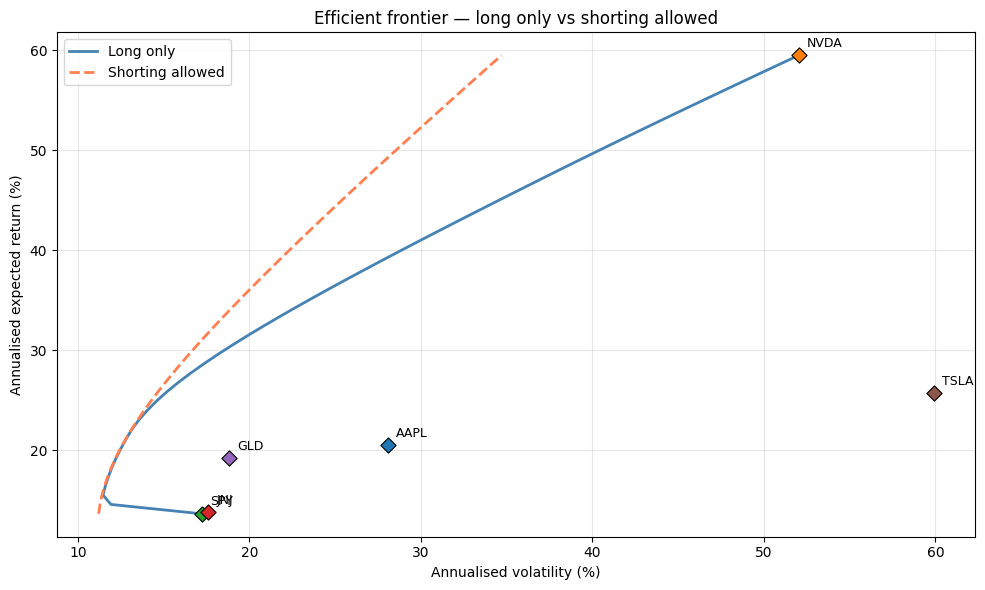

In [108]:
plot_shorting_comparison(mu_arr, cov_arr, tickers)

As seen above, the effective frontier does improve with the allowing of shortages, but cannot take into account extra factors of risk/leverage as mentioned.